**JupyMD** позволяет выполнять Python-блоки внутри заметок Obsidian и синхронизировать Markdown-файл с обычным блокнотом Jupyter `.ipynb`.

Плагин работает только в настольной версии Obsidian. Для него требуется установленный Python.

### Установка

1. Открыть `Настройки → Сторонние плагины → Обзор`.
2. Найти `JupyMD`.
3. Установить и включить плагин.
4. Открыть `Настройки → JupyMD`.
5. Нажать `Select interpreter`.
6. Выбрать `Create virtual environment` — рекомендуемый вариант.
7. Выбрать установленный Python и назвать окружение `.jupymd`.

Плагин создаст окружение в корне хранилища и установит необходимые `jupytext` и `matplotlib`.

Если окружение нужно создать вручную в Windows:

In [ ]:
python -m venv .jupymd
.\.jupymd\Scripts\python.exe -m pip install jupytext matplotlib

После этого в настройках JupyMD нужно выбрать интерпретатор:

```text
<путь к хранилищу>\.jupymd\Scripts\python.exe
```

Папку окружения не следует хранить в Git:

```gitignore
.jupymd/
```

После изменения интерпретатора или настройки `Custom Python code blocks` необходимо перезагрузить Obsidian.

### Первая ячейка

Нужно создать обычный блок кода с языком `python`:

In [ ]:
%%markdown
```python
numbers = [1, 2, 3, 4, 5]
print(sum(numbers))
```

В режиме чтения или Live Preview над ним появится панель JupyMD с кнопкой запуска. После выполнения результат будет показан под блоком:

```text
15
```

Если включена настройка `Automatically convert notes to notebooks on run`, при первом запуске рядом с заметкой автоматически создастся одноимённый файл `.ipynb`.

Например:

```text
Линейная регрессия.md
Линейная регрессия.ipynb
```

Markdown содержит текст и исходный код, а результаты выполнения хранятся в связанном блокноте и отображаются плагином.

### Несколько связанных ячеек

Все Python-блоки заметки выполняются в одном процессе и могут использовать переменные из предыдущих ячеек:

In [ ]:
%%markdown
```python
x = 10
```

```python
print(x * 2)
```

Ячейки необходимо выполнять сверху вниз. После перезапуска Python-процесса состояние теряется, поэтому удобнее выполнить команду:

```text
JupyMD: Run all code blocks in current note
```

Меню возле кнопки запуска позволяет:
- выполнить текущую ячейку;
- выполнить все ячейки выше;
- выполнить текущую и все ячейки ниже.

Кнопка корзины очищает вывод выбранной ячейки.

### Графики

JupyMD умеет отображать графики Matplotlib:

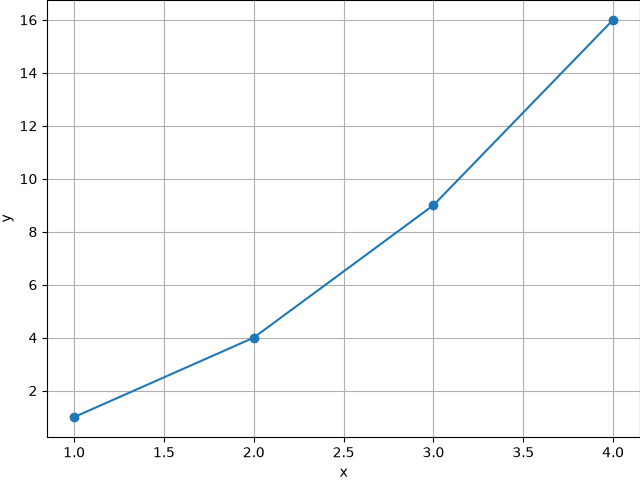

In [4]:
import matplotlib.pyplot as plt

x = [1, 2, 3, 4]
y = [1, 4, 9, 16]

plt.plot(x, y, marker="o")
plt.xlabel("x")
plt.ylabel("y")
plt.grid()
plt.show()

После запуска изображение появится под ячейкой.

### Установка библиотек

Библиотеку нужно устанавливать именно в выбранное окружение JupyMD:

In [ ]:
.\.jupymd\Scripts\python.exe -m pip install numpy pandas scikit-learn

Проверить выбранный интерпретатор можно в строке состояния Obsidian или в `Настройки → JupyMD`.

### Основные команды

Команды вызываются через `Ctrl+P`:
- `JupyMD: Select Python kernel` — выбрать интерпретатор;
- `JupyMD: Create Jupyter notebook from note` — создать связанный `.ipynb`;
- `JupyMD: Create note from Jupyter notebook` — создать Markdown из `.ipynb`;
- `JupyMD: Run all code blocks in current note` — выполнить все ячейки;
- `JupyMD: Clear all code block outputs in current note` — очистить вывод;
- `JupyMD: Sync files` — принудительно синхронизировать файлы;
- `JupyMD: Open Jupyter notebook in editor` — открыть `.ipynb` во внешнем редакторе.

Для открытия через JupyterLab его нужно установить:

In [ ]:
.\.jupymd\Scripts\python.exe -m pip install jupyterlab

В настройке `Jupyter notebook editor launch command` должно быть указано:

```text
jupyter-lab
```

JupyterLab не требуется для выполнения ячеек непосредственно в Obsidian.

### Синхронизация

Рекомендуемые настройки:
- `Automatic sync` — включено;
- `Automatically convert notes to notebooks on run` — включено;
- `Custom Python code blocks` — включено;
- `Bidirectional sync` — выключено, если заметка Obsidian является основным файлом.

При выключенной двусторонней синхронизации изменения `.ipynb` могут быть перезаписаны содержимым Markdown. Если планируется редактировать оба файла, можно включить `Bidirectional sync`, но вероятность конфликтов будет выше.

### Если не работает

**Нет кнопки запуска:**
- проверить, что плагин включён;
- включить `Custom Python code blocks`;
- указать язык блока именно как `python`;
- открыть Live Preview или режим чтения;
- перезагрузить Obsidian.

**Ошибка `No module named ...`:**
- библиотека установлена не в тот Python;
- скопировать путь выбранного интерпретатора из JupyMD;
- установить пакет командой `<интерпретатор> -m pip install <пакет>`.

**Сообщение `Active note is not paired with a notebook`:**
- включить автоматическое создание блокнота при запуске;
- либо выполнить `JupyMD: Create Jupyter notebook from note`.

**Вторая ячейка не видит переменную:**
- сначала выполнить предыдущие ячейки;
- либо использовать `Run all code blocks in current note`.

**Вывод не обновляется:**
- выполнить `JupyMD: Sync files`;
- закрыть и снова открыть заметку;
- проверить, что рядом существует одноимённый `.ipynb`.

Пример использования находится в [[Линейная регрессия#Интерактивный пример в JupyMD]].